<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1> ML </h1></b></center>

<center><b><h1>Lab - 8</b></center>    
<pre>    

# Do all pre processing on diabetes csv

In [21]:
import pandas as pd
import numpy as np

In [43]:
df = pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,Non Diabetic
764,2,122,70,27,0,36.8,0.340,27,Non Diabetic
765,5,121,72,23,112,26.2,0.245,30,Non Diabetic
766,1,126,60,0,0,30.1,0.349,47,Diabetic


In [44]:
df = df.drop_duplicates()

In [45]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,Non Diabetic
764,2,122,70,27,0,36.8,0.340,27,Non Diabetic
765,5,121,72,23,112,26.2,0.245,30,Non Diabetic
766,1,126,60,0,0,30.1,0.349,47,Diabetic


In [46]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# Check the distribution of the target

In [47]:
print(df['Outcome'].value_counts())

Outcome
Non Diabetic    500
Diabetic        268
Name: count, dtype: int64


# Replace zeros with NaN for specific columns

In [48]:
columns_with_zero = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[columns_with_zero] = df[columns_with_zero].replace(0,np.nan)

# Check for missing values

In [49]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

# Fill missing values with median

In [50]:
for c in columns_with_zero:
    df[columns_with_zero] = df[columns_with_zero].fillna(df[columns_with_zero].median())

In [51]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# Convert Targer data into interger code

In [52]:
df['Outcome'] = df['Outcome'].map({'Non Diabetic': 0,'Diabetic': 1})

In [53]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


# Visualize Distributions

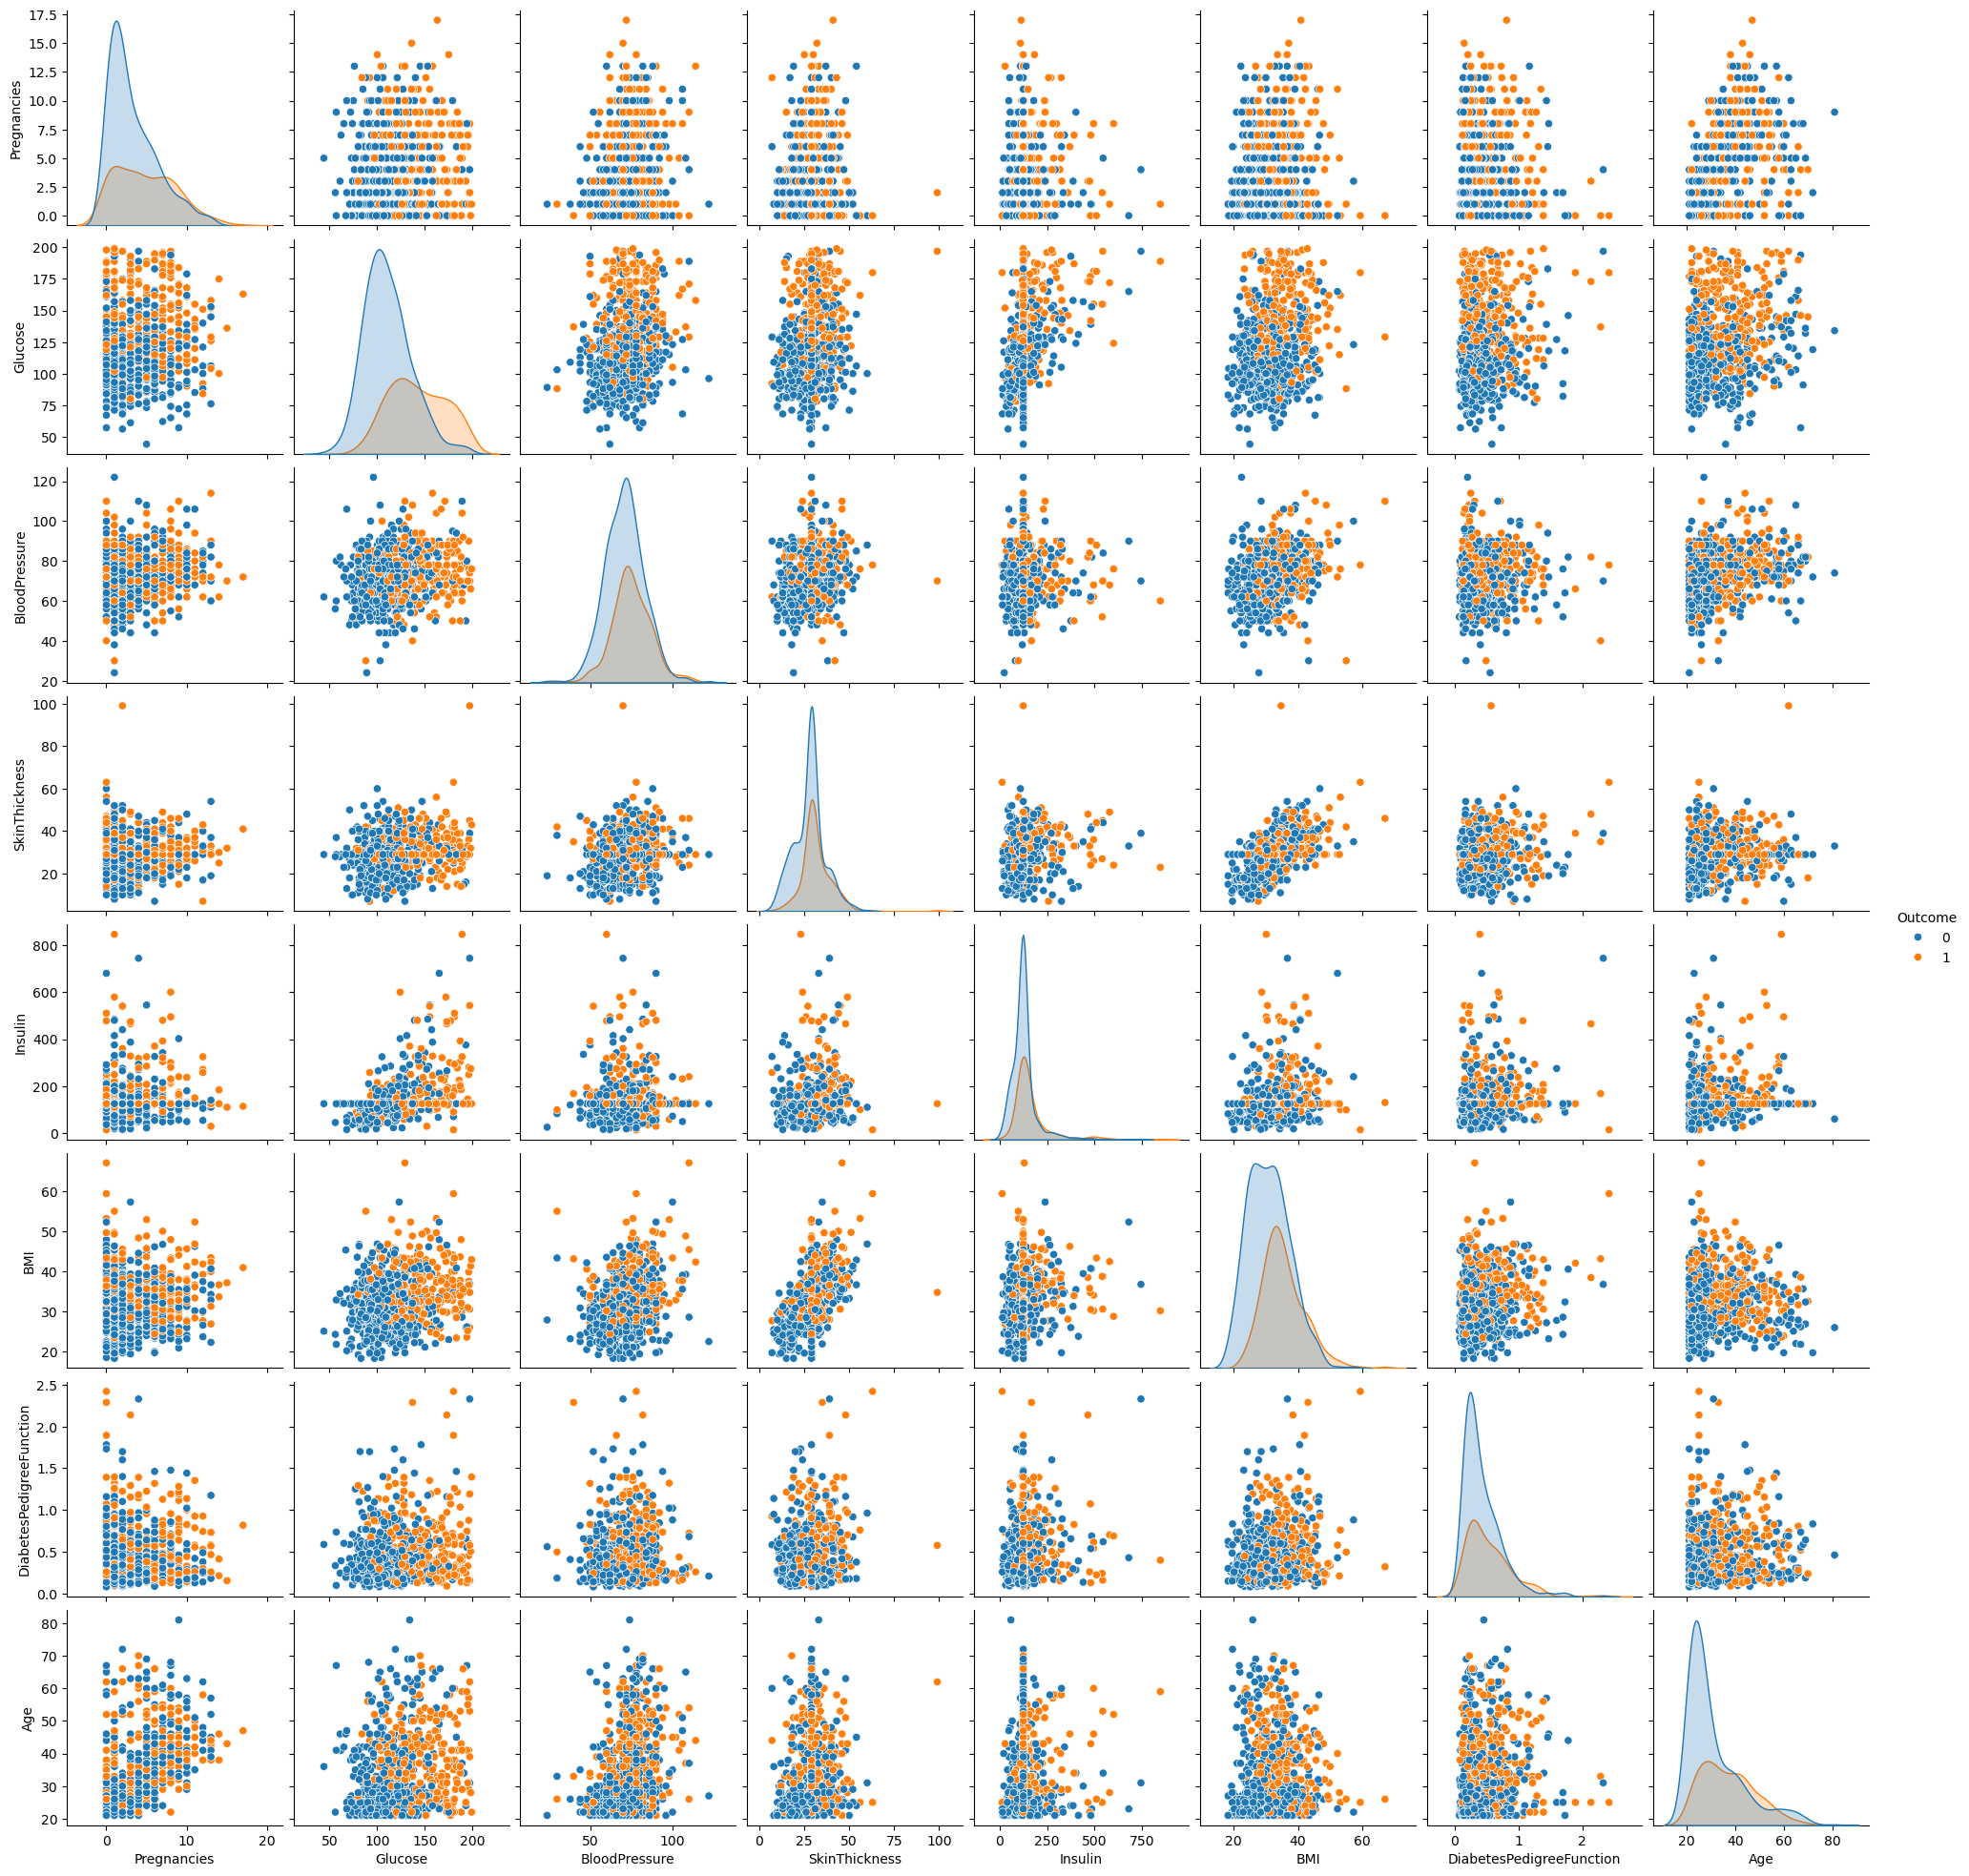

In [54]:
import seaborn as sns

sns.pairplot(df,hue = 'Outcome')

In [55]:
corr = df.corr()

<Axes: >

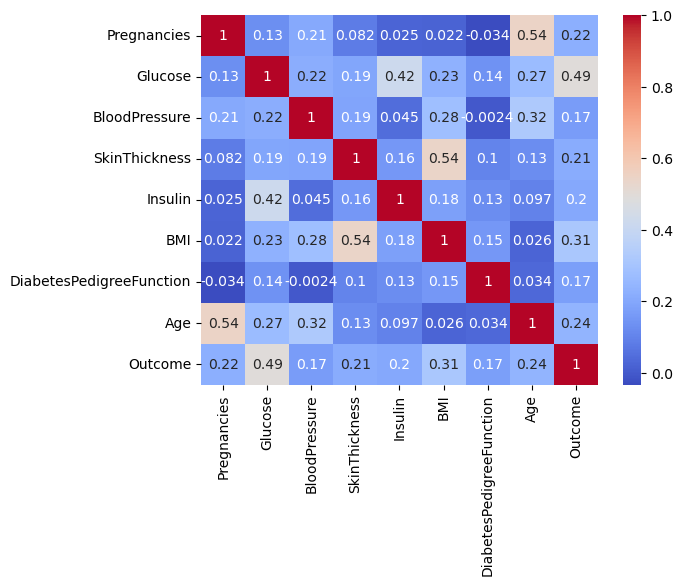

In [57]:
sns.heatmap(corr,annot=True,cmap='coolwarm')

# Divide the data into input and output

In [58]:
x = df.iloc[::,:8:]
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47


In [59]:
y = df['Outcome']
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

# import KNN Model

In [60]:
from sklearn.neighbors import KNeighborsClassifier

# Splitting the dataset into the Training set and Test set

In [61]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

# Convert all features into Z score

In [63]:
from sklearn.preprocessing import StandardScaler

In [65]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_train)

In [66]:
x_test_scaler = scaler.transform(x_test)

In [67]:
x_scaled

array([[-1.148112  ,  0.85824047,  0.80699054, ...,  1.12681085,
         3.75468215,  0.93946023],
       [ 0.94184103,  2.46489356, -0.34183637, ...,  0.48311996,
         0.77528011,  0.67905582],
       [-0.55098256,  0.05491393, -0.17771824, ...,  0.60905948,
        -0.38944752, -0.53616476],
       ...,
       [ 0.04614687, -1.01618813,  1.29934493, ...,  0.734999  ,
        -0.32617836, -0.36256182],
       [ 1.83753519,  0.05491393, -0.34183637, ..., -0.17456422,
        -0.62526891,  0.67905582],
       [ 2.1360999 ,  0.75782465,  1.79169932, ...,  0.58107292,
        -0.6367724 ,  1.54707052]])

# Create KNN Model

In [127]:
model = KNeighborsClassifier()

In [128]:
model

KNeighborsClassifier()

# Fitting KNN   on dataset

In [129]:
model.fit(x_scaled,y_train)

KNeighborsClassifier()

In [130]:
y_pred = model.predict(x_test_scaler)

In [131]:
y_pred

array([1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0], dtype=int64)

# Display classification_report

In [132]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [133]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7186147186147186

Confusion Matrix:
 [[117  23]
 [ 42  49]]

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.84      0.78       140
           1       0.68      0.54      0.60        91

    accuracy                           0.72       231
   macro avg       0.71      0.69      0.69       231
weighted avg       0.71      0.72      0.71       231



In [134]:
model.score(x_test_scaler,y_test)

0.7186147186147186

In [135]:
cm = confusion_matrix(y_test, y_pred)

In [136]:
display = ConfusionMatrixDisplay(cm,display_labels=['0','1'])

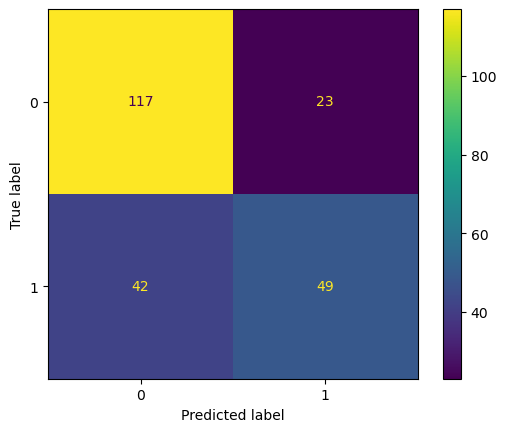

In [137]:
display.plot()

# Method to decide best Value of K is Square Root of N

In [ ]:
import math

In [ ]:
n_train_samples = len(x_train)
k_sqrt = int(math.sqrt(n_train_samples))

# Ensure k is odd to avoid ties in binary classification
if k_sqrt % 2 == 0:
    k_sqrt += 1

print(f"Training samples: {n_train_samples}")
print(f"Calculated k (sqrt(n)): {k_sqrt}\n")

Training samples: 537
Calculated k (sqrt(n)): 23

